In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

model = tf.keras.models.load_model("Fish_MN.keras")

CLASS_NAMES = [
    "Black Sea Sprat",
    "Gilt-Head Bream",
    "Hourse Mackerel",
    "Red Mullet",
    "Red Sea Bream",
    "Sea Bass",
    "Shrimp",
    "Striped Red Mullet",
    "Trout",
]

I0000 00:00:1776003399.951262  429206 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776003405.781040  429206 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4770 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:01:00.0, compute capability: 8.6


In [3]:
def load_preprocess_for_model(img_path, target_size=(224, 224)):
    img = Image.open(img_path).convert("RGB").resize(target_size)
    arr = np.array(img).astype("float32")
    arr = preprocess_input(arr)
    img_tensor = np.expand_dims(arr, axis=0)
    return img, arr, img_tensor  # PIL image, preprocessed array, batch tensor

In [4]:
def integrated_gradients(img_tensor, model, target_class_idx, baseline=None, steps=32):
    """
    img_tensor: (1, H, W, 3) already preprocessed (MobileNetV2 preprocess_input)
    baseline: same shape as img_tensor. If None, uses zeros.
    returns:
      attributions: (H, W, 3) numpy array
    """
    if baseline is None:
        baseline = tf.zeros_like(img_tensor)

    # Scale inputs from baseline -> input
    alphas = tf.linspace(0.0, 1.0, steps + 1)  # includes endpoints

    # Collect gradients along the path
    grads_list = []
    for alpha in alphas:
        x = baseline + alpha * (img_tensor - baseline)
        with tf.GradientTape() as tape:
            tape.watch(x)
            preds = model(x, training=False)
            score = preds[:, target_class_idx]  # scalar per batch
        grads = tape.gradient(score, x)  # (1,H,W,3)
        grads_list.append(grads)

    grads = tf.stack(grads_list, axis=0)  # (steps+1, 1, H, W, 3)

    # Average gradients using trapezoidal rule: avg of consecutive grads
    grads_mid = (grads[:-1] + grads[1:]) / 2.0  # (steps, 1, H, W, 3)
    avg_grads = tf.reduce_mean(grads_mid, axis=0)  # (1,H,W,3)

    # Integrated gradients
    attributions = (img_tensor - baseline) * avg_grads  # (1,H,W,3)
    return attributions[0].numpy()

In [5]:
def ig_to_heatmap(ig_attributions):
    """
    ig_attributions: (H,W,3) array
    returns: (H,W) heatmap in [0,1]
    """
    # Standard approach: take channel-wise absolute importance then normalize
    heat = np.sum(np.abs(ig_attributions), axis=-1)  # (H,W)
    heat = heat - heat.min()
    heat = heat / (heat.max() + 1e-8)
    return heat

In [6]:
def visualize_integrated_gradients(img_path, model, target_class_idx=None, steps=32, alpha=0.45):
    pil_img, arr, img_tensor = load_preprocess_for_model(img_path)

    preds = model.predict(img_tensor, verbose=0)[0]
    pred_idx = int(np.argmax(preds))

    if target_class_idx is None:
        target_class_idx = pred_idx

    ig_attr = integrated_gradients(img_tensor, model, target_class_idx, steps=steps)
    heat = ig_to_heatmap(ig_attr)

    # Overlay heatmap
    heat_uint8 = (heat * 255).astype(np.uint8)
    plt_heat = plt.cm.jet(heat_uint8 / 255.0)[:, :, :3]  # (H,W,3) RGB
    plt_heat = (plt_heat * 255).astype(np.uint8)

    overlay = (
        np.array(pil_img).astype(np.float32) * (1 - alpha) +
        plt_heat.astype(np.float32) * alpha
    ).astype(np.uint8)

    # Plot
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(pil_img)
    plt.axis("off")
    plt.title(f"Original\nPred: {CLASS_NAMES[pred_idx]} ({preds[pred_idx]*100:.1f}%)")

    plt.subplot(1, 3, 2)
    plt.imshow(heat, cmap="jet")
    plt.axis("off")
    plt.title(f"Integrated Gradients Heatmap\nClass: {CLASS_NAMES[target_class_idx]}")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.axis("off")
    plt.title("Overlay")

    plt.tight_layout()
    plt.show()

    return {
        "pred_idx": pred_idx,
        "target_class_idx": target_class_idx,
        "pred_probs": preds,
        "ig_attributions": ig_attr,
        "heatmap": heat,
    }

I0000 00:00:1776003422.390661  429667 cuda_dnn.cc:461] Loaded cuDNN version 92000


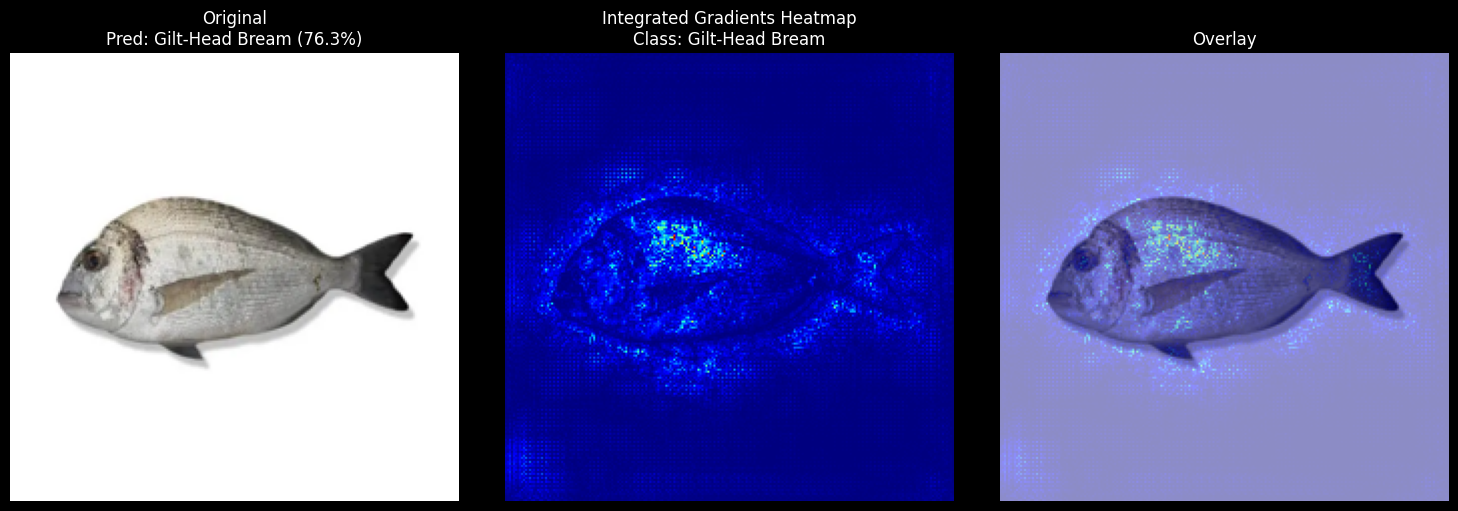

In [7]:
img_path = "/home/groggy/data/a-large-scale-fish-dataset/2/urelaterte_bilder/Gilt_head_bream.webp"
result = visualize_integrated_gradients(img_path, model, target_class_idx=None, steps=32)

Predicted: Gilt-Head Bream (class 1) prob=76.33%


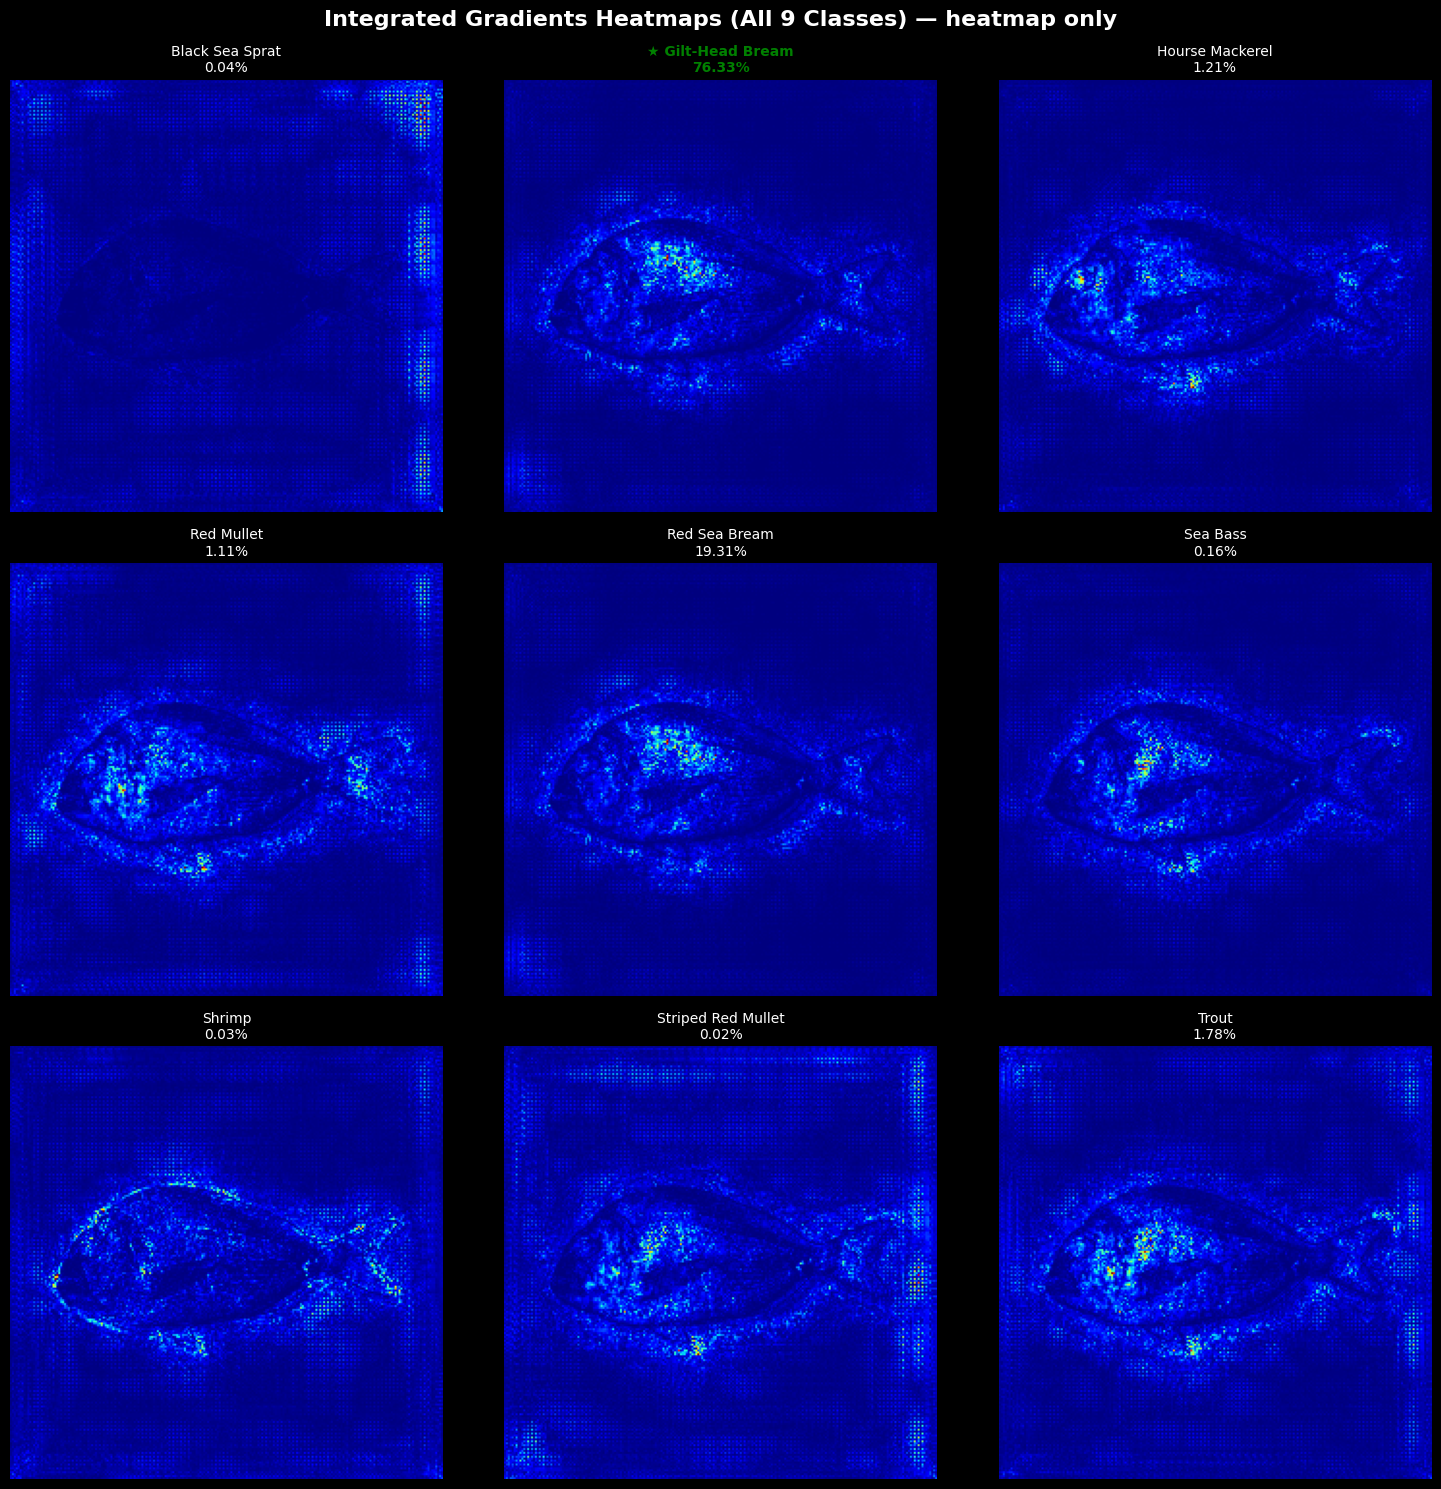

In [11]:
steps = 32  # IG steps; increase for smoother heatmaps

model = tf.keras.models.load_model("Fish_MN.keras")

def load_preprocess_for_model(img_path, target_size=(224, 224)):
    img = Image.open(img_path).convert("RGB").resize(target_size)
    arr = np.array(img).astype("float32")
    arr = preprocess_input(arr)
    img_tensor = np.expand_dims(arr, axis=0)
    return img, arr, img_tensor

def integrated_gradients(img_tensor, model, target_class_idx, baseline=None, steps=32):
    if baseline is None:
        baseline = tf.zeros_like(img_tensor)

    alphas = tf.linspace(0.0, 1.0, steps + 1)  # includes endpoints

    grads_list = []
    for alpha in alphas:
        x = baseline + alpha * (img_tensor - baseline)
        with tf.GradientTape() as tape:
            tape.watch(x)
            preds = model(x, training=False)
            score = preds[:, target_class_idx]  # scalar per batch
        grads = tape.gradient(score, x)  # (1,H,W,3)
        grads_list.append(grads)

    grads = tf.stack(grads_list, axis=0)  # (steps+1,1,H,W,3)

    # trapezoidal rule average of consecutive gradients
    grads_mid = (grads[:-1] + grads[1:]) / 2.0  # (steps,1,H,W,3)
    avg_grads = tf.reduce_mean(grads_mid, axis=0)  # (1,H,W,3)

    attributions = (img_tensor - baseline) * avg_grads  # (1,H,W,3)
    return attributions[0].numpy()  # (H,W,3)

def ig_to_heatmap(ig_attributions):
    heat = np.sum(np.abs(ig_attributions), axis=-1)  # (H,W)
    heat = heat - heat.min()
    heat = heat / (heat.max() + 1e-8)
    return heat

# -----------------------
# Run IG for all classes
# -----------------------
pil_img, arr, img_tensor = load_preprocess_for_model(img_path)

probs = model.predict(img_tensor, verbose=0)[0]
pred_class = int(np.argmax(probs))
print(f"Predicted: {CLASS_NAMES[pred_class]} (class {pred_class}) prob={probs[pred_class]*100:.2f}%")

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for class_idx in range(9):
    ig_attr = integrated_gradients(
        img_tensor=img_tensor,
        model=model,
        target_class_idx=class_idx,
        baseline=None,
        steps=steps
    )
    heatmap = ig_to_heatmap(ig_attr)

    ax = axes[class_idx]
    ax.imshow(heatmap, cmap="jet")
    ax.axis("off")

    title = f"{CLASS_NAMES[class_idx]}\n{probs[class_idx]*100:.2f}%"
    if class_idx == pred_class:
        title = "★ " + title
    axes[class_idx].set_title(
        title,
        fontsize=10,
        fontweight="bold" if class_idx == pred_class else "normal",
        color="green" if class_idx == pred_class else "white"
    )

plt.suptitle("Integrated Gradients Heatmaps (All 9 Classes) — heatmap only", fontsize=16, fontweight="bold", y=0.99)
plt.tight_layout()
plt.savefig("images/integrated_gradients_all_classes_grid.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

img_path = "/home/groggy/data/a-large-scale-fish-dataset/2/urelaterte_bilder/Gilt_head_bream.webp"
steps = 32

CLASS_NAMES = [
    "Black Sea Sprat",
    "Gilt-Head Bream",
    "Hourse Mackerel",
    "Red Mullet",
    "Red Sea Bream",
    "Sea Bass",
    "Shrimp",
    "Striped Red Mullet",
    "Trout",
]

model = tf.keras.models.load_model("Fish_MN.keras")

def load_preprocess_for_model(img_path, target_size=(224, 224)):
    img = Image.open(img_path).convert("RGB").resize(target_size)
    arr = np.array(img).astype("float32")
    arr = preprocess_input(arr)
    img_tensor = np.expand_dims(arr, axis=0)
    return img, arr, img_tensor

def integrated_gradients(img_tensor, model, target_class_idx, baseline=None, steps=32):
    if baseline is None:
        baseline = tf.zeros_like(img_tensor)

    alphas = tf.linspace(0.0, 1.0, steps + 1)

    grads_list = []
    for alpha in alphas:
        x = baseline + alpha * (img_tensor - baseline)
        with tf.GradientTape() as tape:
            tape.watch(x)
            preds = model(x, training=False)
            score = preds[:, target_class_idx]
        grads = tape.gradient(score, x)
        grads_list.append(grads)

    grads = tf.stack(grads_list, axis=0)  # (steps+1,1,H,W,3)
    grads_mid = (grads[:-1] + grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(grads_mid, axis=0)  # (1,H,W,3)

    attributions = (img_tensor - baseline) * avg_grads
    return attributions[0].numpy()

def ig_to_heatmap(ig_attributions):
    heat = np.sum(np.abs(ig_attributions), axis=-1)
    heat = heat - heat.min()
    heat = heat / (heat.max() + 1e-8)
    return heat

pil_img, arr, img_tensor = load_preprocess_for_model(img_path)

probs = model.predict(img_tensor, verbose=0)[0]
pred_class = int(np.argmax(probs))
print(f"Predicted: {CLASS_NAMES[pred_class]} (class {pred_class}) prob={probs[pred_class]*100:.2f}%")

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for class_idx in range(9):
    ig_attr = integrated_gradients(
        img_tensor=img_tensor,
        model=model,
        target_class_idx=class_idx,
        baseline=None,
        steps=steps
    )
    heatmap = ig_to_heatmap(ig_attr)

    axes[class_idx].imshow(heatmap, cmap="jet")
    axes[class_idx].axis("off")

    title = f"{CLASS_NAMES[class_idx]}\n{probs[class_idx]*100:.2f}%"
    if class_idx == pred_class:
        title = "★ " + title
    axes[class_idx].set_title(title, fontsize=10, fontweight="bold" if class_idx == pred_class else "normal")

plt.suptitle("Integrated Gradients Heatmaps (All 9 Classes) — heatmap only", fontsize=16, fontweight="bold", y=0.99)
plt.tight_layout()
plt.savefig("images/integrated_gradients_all_classes_grid.png", dpi=150, bbox_inches="tight")
plt.show()